# VarDyn BM-IT JET run
Run the coupled balanced-motion/internal-tide 4DVar configuration for the JET BM-IT OSSE. The analysis assimilates total SLA and jointly estimates the BM SLA state and IT controls.

Select the GPU before importing VarDyn/JAX. Set `NUM_GPU` to the device visible to this notebook session.

In [1]:
import os
NUM_GPU = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = NUM_GPU

In [2]:
path_config = 'config_VarDyn-BMIT-JET.py'
mapping_root = '/home/flo/VarDyn/mapping'

import sys
if mapping_root not in sys.path:
    sys.path.append(mapping_root)

## Build the assimilation components
The configuration merges its nested `MOD_QG1L` BM and `MOD_CSW1L` IT blocks with the current VarDyn defaults. Check the data paths and `myPath` in the config before running this cell.

name_experiment: VarDyn-BMIT-JET
name_exp_save: VarDyn-BMIT-JET
path_save: ./outputs/VarDyn-BMIT-JET
tmp_DA_path: ./scratch/VarDyn-BMIT-JET
init_date: 2010-05-01 00:00:00
final_date: 2010-07-01 00:00:00
assimilation_time_step: 1:00:00
saveoutput_time_step: 3:00:00
flag_plot: 1
write_obs: True
path_obs: ./obs
compute_obs: True
saveoutputs: True
name_lon: lon
name_lat: lat
name_time: time
plot_time_step: 1 day, 0:00:00
time_obs_min: None
time_obs_max: None
lon_obs_min: None
lon_obs_max: None
lat_obs_min: None
lat_obs_max: None

super: GRID_FROM_FILE
path_init_grid: /data1/data/models/JET_BM-IT/full_resolution/vmodes_jet_cfg1_wp6_2d_coarse2.nc
name_init_lon: lon
name_init_lat: lat
subsampling: None
name_init_mask: None
name_var_mask: {'lon': '', 'lat': '', 'var': ''}

No mask provided


super: MOD_BMIT
name_var: {'U_IT': 'u_it', 'V_IT': 'v_it', 'SSH_IT': 'sla_it', 'U_BM': 'u_bm', 'V_BM': 'v_bm', 'SSH_BM': 'sla_bm', 'SSH': 'sla'}
name_init_var: {}
var_to_save: None
dtmodel: 300
bm_model: {'super': 'MOD_QG1L', 'name_params': None, 'dtmodel': 300, 'cfl': 0.3, 'time_scheme': 'rk2', 'Kdiffus': 150, 'init_from_bc': True, 'path_mdt': '/data1/data/models/JET_BM-IT/full_resolution/vmodes_jet_cfg1_wp6_2d_coarse2.nc', 'name_var_mdt': {'lon': 'lon', 'lat': 'lat', 'var': 'mdt'}, 'filec_aux': '/data1/data/models/JET_BM-IT/full_resolution/vmodes_jet_cfg1_wp6_2d_coarse2.nc', 'name_var_c': {'lon': 'lon', 'lat': 'lat', 'var': 'c1'}, 'bc_file': '/data1/data/models/JET_BM-IT/full_resolution/wp6_surf_data_ref_coarse2.nc', 'bc_name_lon': 'lon', 'bc_name_lat': 'lat', 'bc_name_time': 'time', 'bc_name_var': {'SSH': 'sla_bm'}, 'bc_c_grid': False, 'name_class': 'Qgm', 'formulation': 'ssh', 'name_var': {'SSH': 'ssh'}, 'name_init_var': {}, 'dir_model': None, 'var_to_save': None, 'save_diagnosed_v

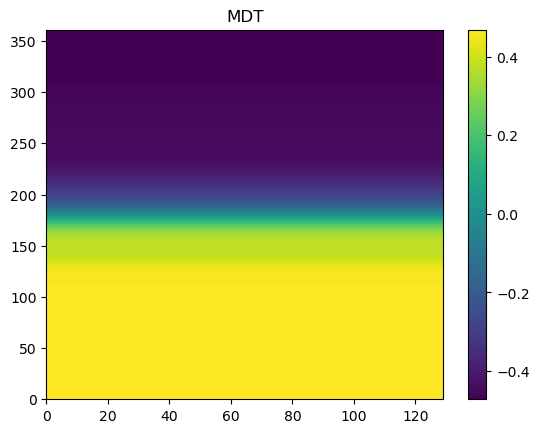

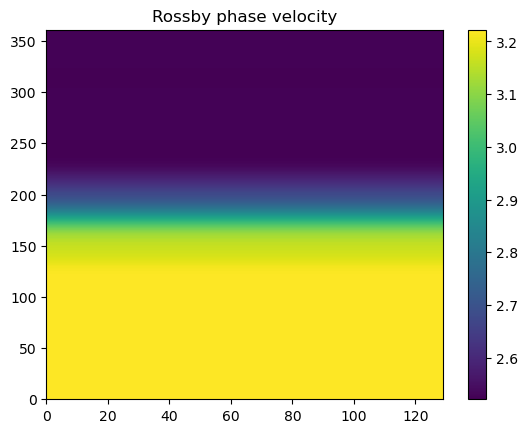

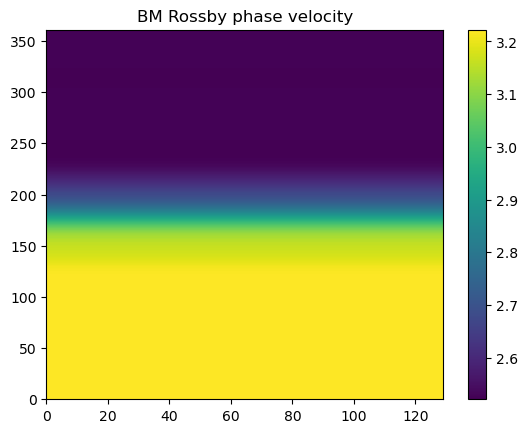

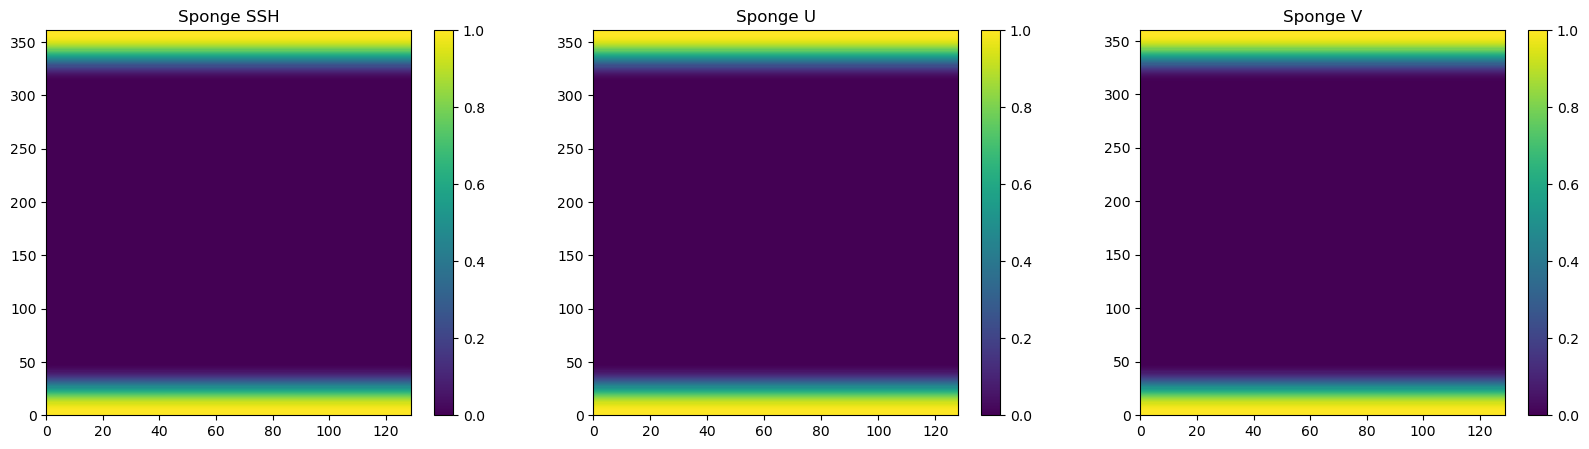

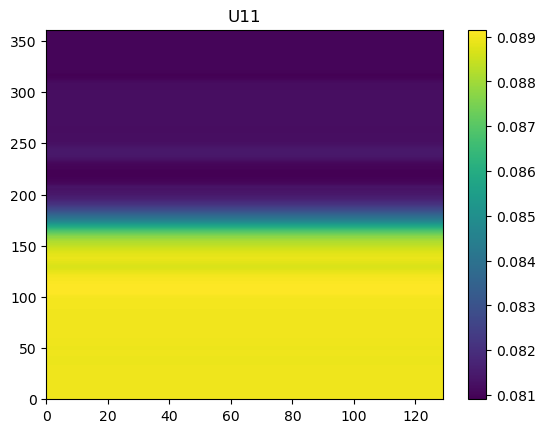

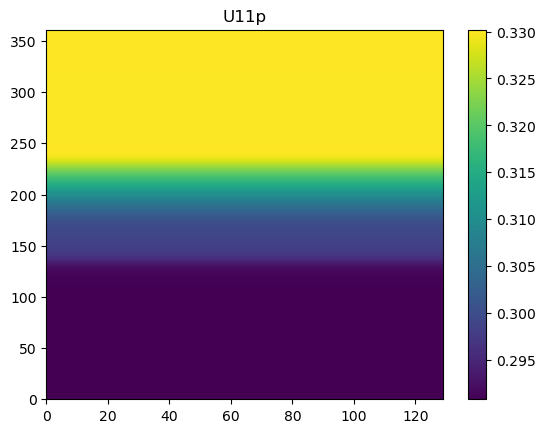

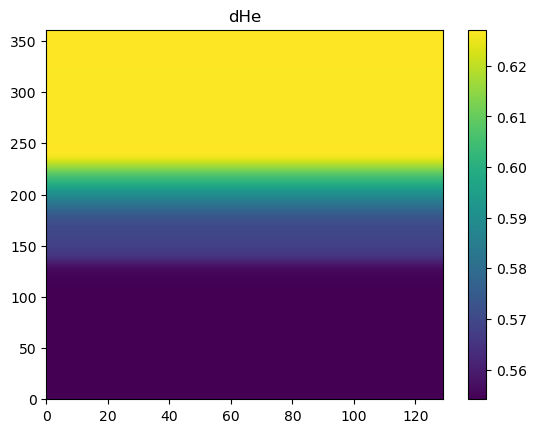

  - f₀ (s⁻¹):             1.0422e-04
  - c  (m/s):              2.8758
  - Rd = c/|f₀| (km):   27.6


/home/flo/VarDyn/mapping/src/mod.py:5720: UserWarning: CSWm: Ntheta=1 is below the boundary Nyquist minimum Ntheta_min=27 (lambda_min=108.9 km, L_bdy=2886.2 km). Aliasing in along-boundary wave angle. Consider increasing Ntheta or setting Ntheta=-1 for auto.
  self.model_it = model_it(


Observation information will be saved in dict_obs_NR_20100501_20100701_291_308_33_59_3600.txt

NR:
super: OBS_L4
path: /data1/data/models/JET_BM-IT/full_resolution/wp6_surf_data_ref_coarse2.nc
name_time: time
name_lon: lon
name_lat: lat
name_var: {'SSH': 'sla'}
name_err: {}
subsampling: 81
sigma_noise: 0.02
offset: None



--> 6 fields selected
super: OBSOP_INTERP_L4
name_obs: ['NR']
name_var: SSH
write_op: True
path_save: ./H
compute_op: True
mask_borders: False
interp_method: linear
gradients: False

super: BASIS_GAUSS3D
name_mod_var: sla_bm
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: False
facns: 2.0
facnlt: 2.0
sigma_D: 300
sigma_T: 20
sigma_Q: 0.02
facQ: 1.0
normalize_fact: False
time_spinup: None
flag_variable_Q: False
path_sad: None
name_var_sad: {'lon': '', 'lat': '', 'var': ''}
path_background: None
var_background: None

super: BASIS_GAUSS3D
name_mod_var: He_mean
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: False
facns: 2.0
facnlt: 2.0
sigma_D: 1000
sigma_T: 50
sigma_Q: 0.01
facQ: 1.0
normalize_fact: False
time_spinup: None
flag_variable_Q: False
path_sad: None
name_var_sad: {'lon': '', 'lat': '', 'var': ''}
path_background: None
var_background: None

super: BASIS_OFFSET
name_mod_var: alpha_He
sigma_B: 0.1

super: BASIS_OFFSET
name

In [3]:
from src import basis, exp, mod, obs, obsop, state

config = exp.Exp(path_config)
State = state.State(config)
Model = mod.Model(config, State)
dict_obs = obs.Obs(config, State)
Obsop = obsop.Obsop(config, State, dict_obs, Model)
Basis = basis.Basis(config, State)

## Run the coupled 4DVar inversion
This can be computationally expensive. Cached observations and interpolation operators are reused when `compute_obs = False` in the configuration.

super: INV_4DVAR
compute_test: False
freq_it_plot: 10
print_time: False
JAX_mem_fraction: None
path_init_4Dvar: None
restart_4Dvar: False
ftol: 5e-05
gtol: None
convergence_nit: None
maxiter: 50
gradient_max_norm: 1000000.0
max_retries: 5
opt_method: L-BFGS-B
save_minimization: True
path_save_control_vectors: ./controls/VarDyn-BMIT-JET
timestep_checkpoint: 1 day, 0:00:00
sigma_R: None
sigma_B: None
prec: True
path_background: None
anomaly_from_bc: False

process observation operators
Processing observations at date 2010-05-02 12:00:00 for variable SSH...


Processing observations at date 2010-05-12 15:00:00 for variable SSH...


Processing observations at date 2010-05-22 18:00:00 for variable SSH...


Processing observations at date 2010-06-01 21:00:00 for variable SSH...


Processing observations at date 2010-06-12 00:00:00 for variable SSH...


Processing observations at date 2010-06-22 03:00:00 for variable SSH...


--> 67 checkpoints to evaluate the cost function


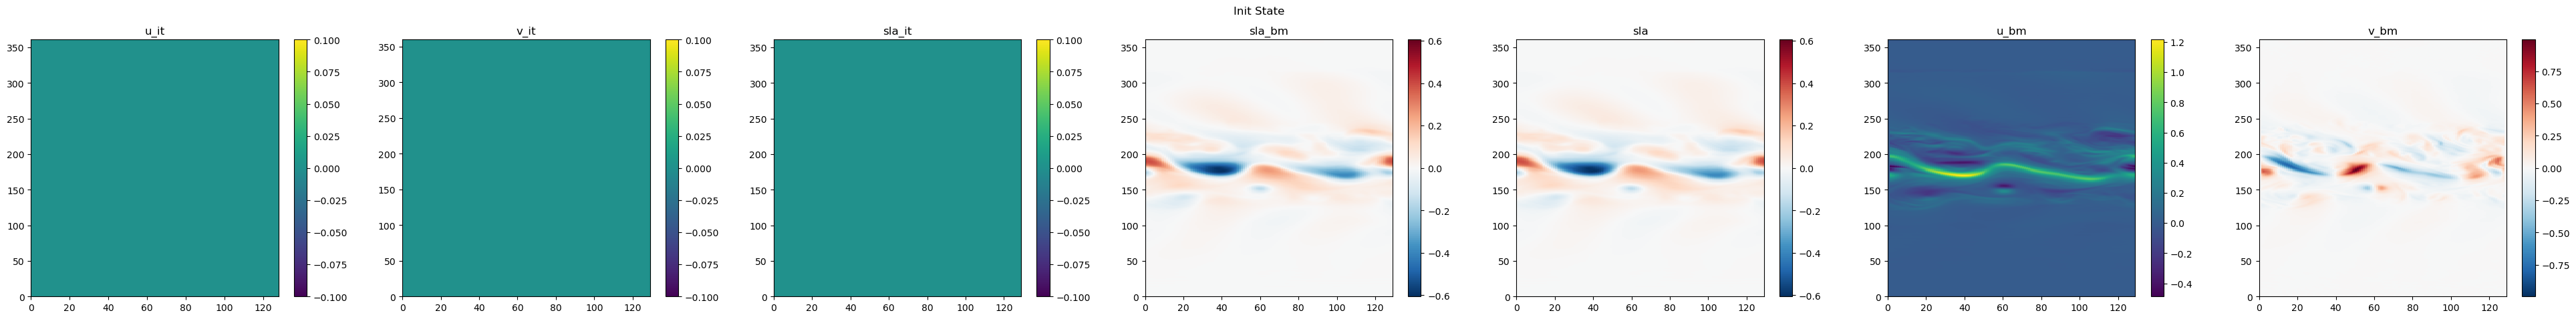

Can't plot parameters
Can't plot parameters


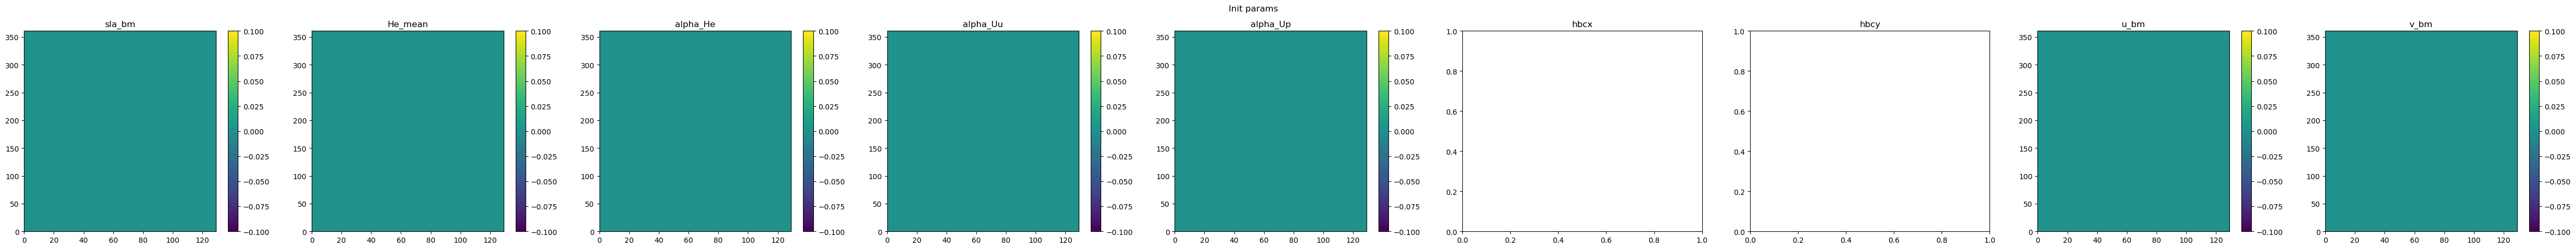

lambda=3.0E+02 nlocs=2.8E+02 tdec=2.0E+01 ntime=9.0E+00 Q=1.0E-02
reduced order: 2887278 --> 2502
 reduced factor: 1153


lambda=1.0E+03 nlocs=5.6E+01 tdec=5.0E+01 ntime=5.0E+00 Q=5.0E-03
reduced order: 2887278 --> 280
 reduced factor: 10311


nbcx: 108


nbcy: 168
reduced order: 364560 --> 276
reduced factor: 1320

*** Minimization ***



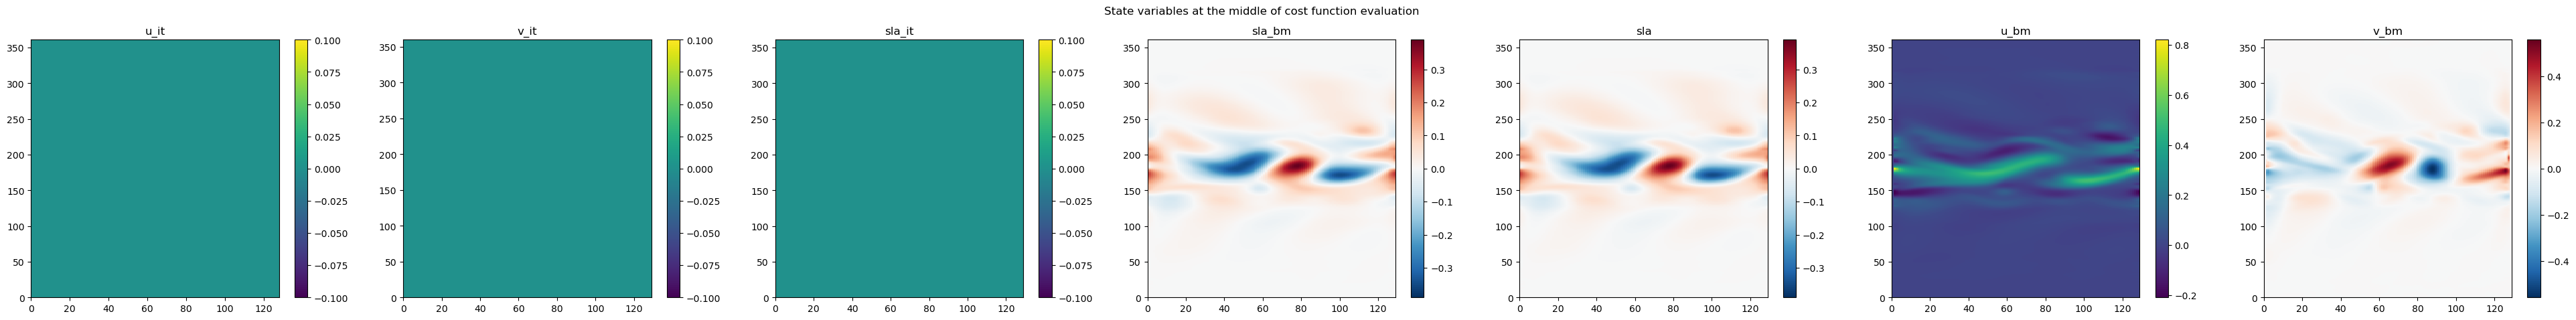

Can't plot parameters
Can't plot parameters


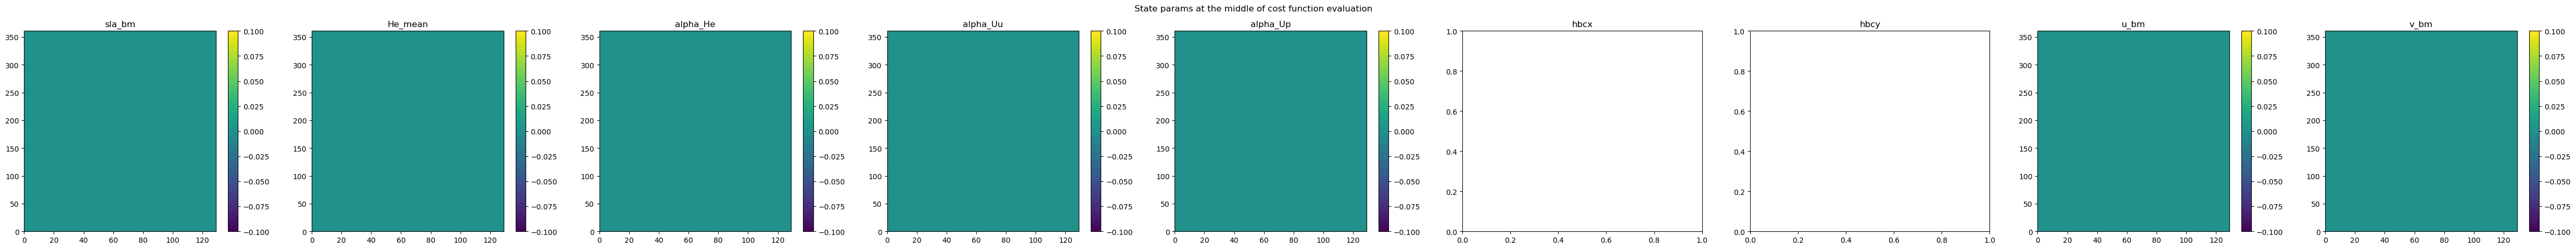

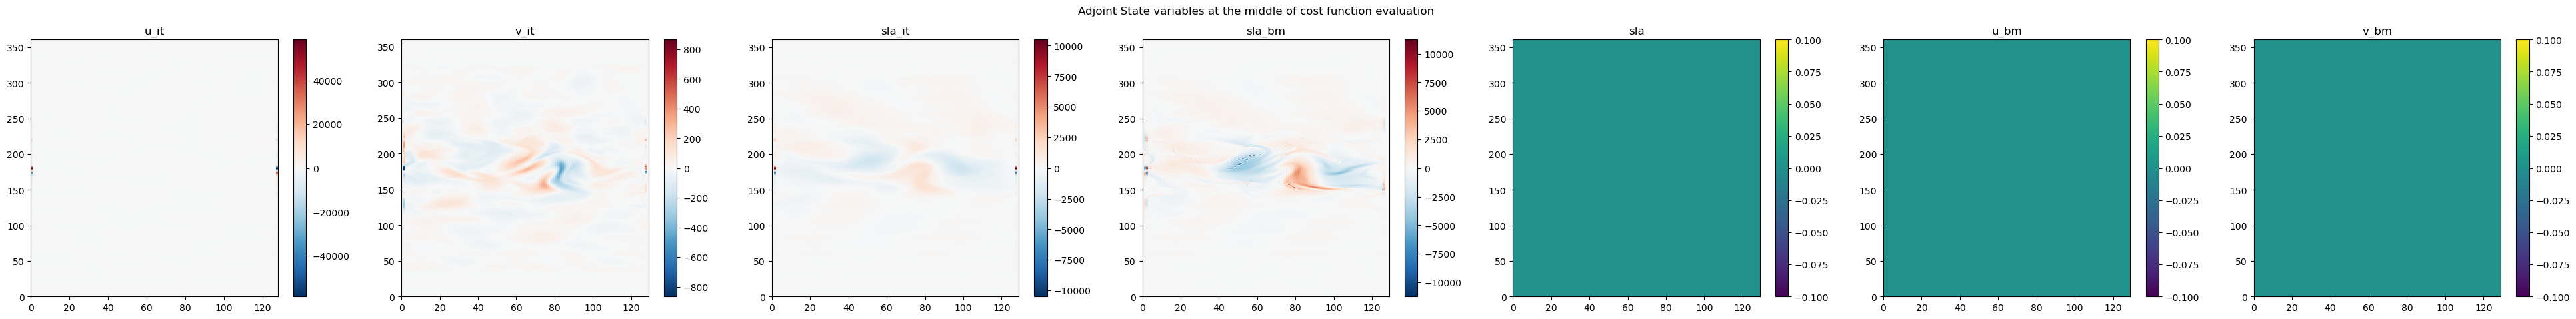

[cost] first evaluation compile+run time: 302.59 seconds


* iteration 1 computed in 1.72E+01 second:, x=0.00E+00, J=1.54E+06, G=7.05E+03, ftol=0.00E+00, gtol=1.07E-11


* iteration 2 computed in 1.72E+01 second:, x=-2.98E-05, J=1.21E+06, G=9.62E+03, ftol=2.17E-01, gtol=2.67E-01


* iteration 3 computed in 1.72E+01 second:, x=-4.57E-05, J=8.56E+05, G=3.40E+03, ftol=2.91E-01, gtol=6.46E-01


* iteration 4 computed in 1.73E+01 second:, x=2.61E-04, J=7.45E+05, G=2.68E+03, ftol=1.30E-01, gtol=2.13E-01


* iteration 5 computed in 1.73E+01 second:, x=5.47E-04, J=6.34E+05, G=2.57E+03, ftol=1.49E-01, gtol=4.17E-02


* iteration 6 computed in 1.73E+01 second:, x=2.21E-03, J=5.84E+05, G=5.49E+03, ftol=7.89E-02, gtol=5.32E-01


* iteration 7 computed in 1.73E+01 second:, x=1.54E-03, J=5.14E+05, G=1.91E+03, ftol=1.20E-01, gtol=6.52E-01


* iteration 8 computed in 1.73E+01 second:, x=1.30E-03, J=4.86E+05, G=1.49E+03, ftol=5.35E-02, gtol=2.22E-01


* iteration 9 computed in 1.73E+01 second:, x=1.20E-03, J=4.61E+05, G=1.53E+03, ftol=5.16E-02, gtol=2.99E-02


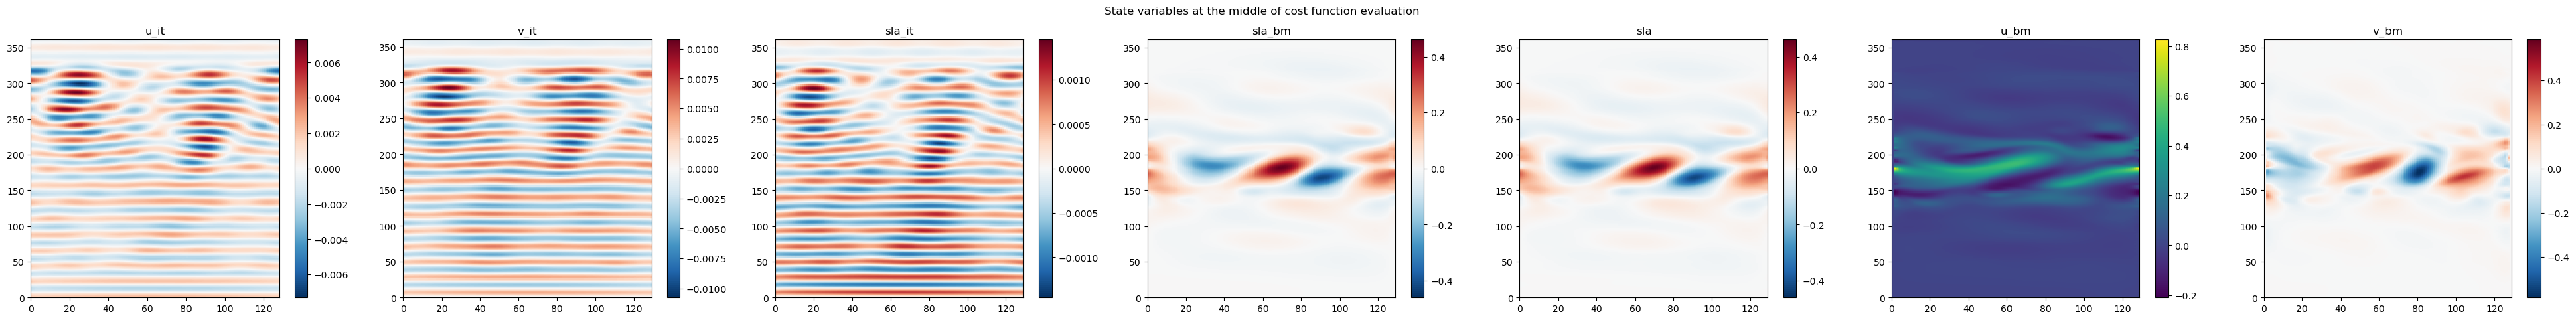

Can't plot parameters
Can't plot parameters


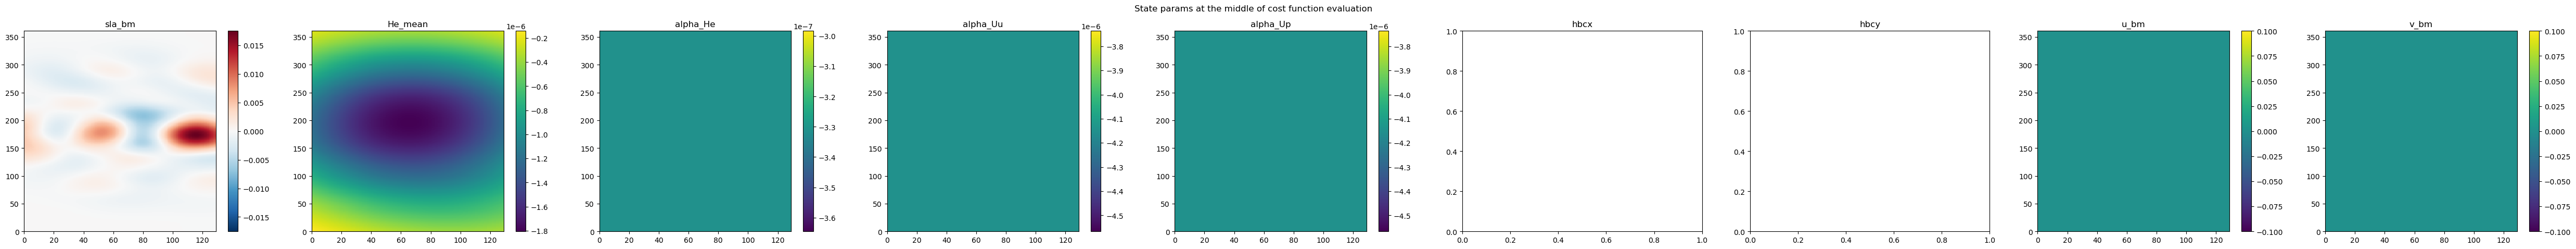

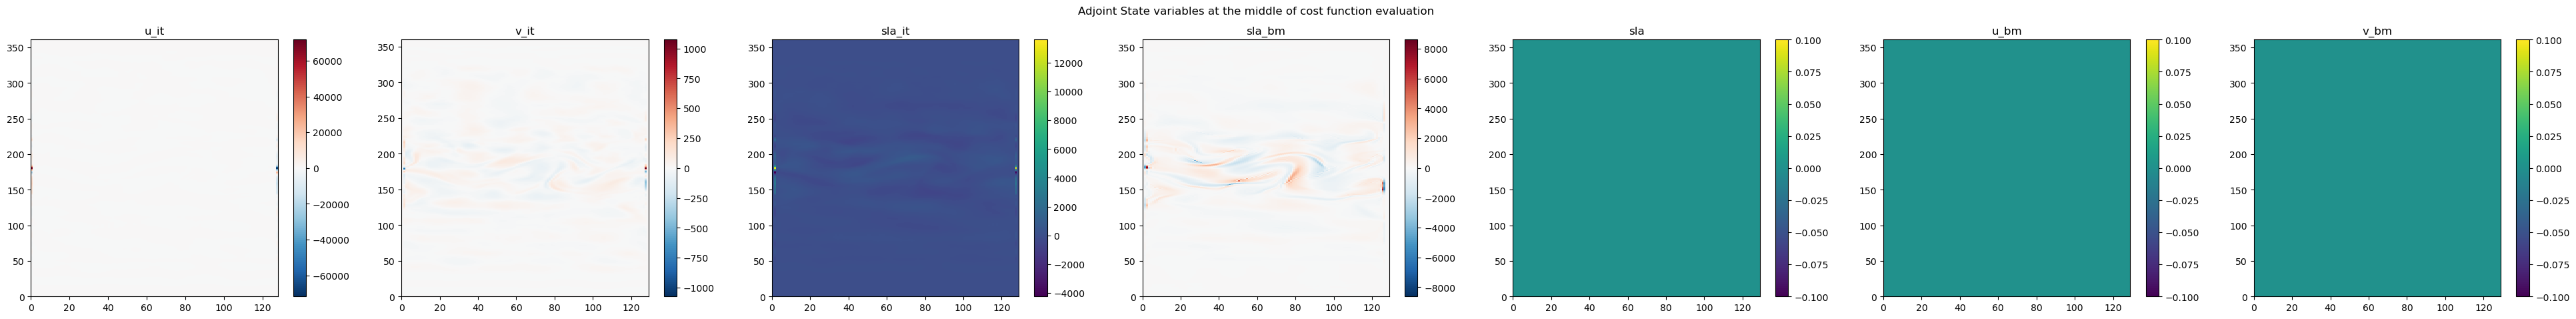

* iteration 10 computed in 2.14E+01 second:, x=9.94E-04, J=4.26E+05, G=1.85E+03, ftol=7.57E-02, gtol=1.71E-01


* iteration 11 computed in 1.73E+01 second:, x=7.45E-04, J=4.25E+05, G=3.27E+03, ftol=3.93E-03, gtol=4.35E-01


* iteration 12 computed in 1.72E+01 second:, x=8.68E-04, J=4.06E+05, G=1.67E+03, ftol=4.38E-02, gtol=4.89E-01


* iteration 13 computed in 1.73E+01 second:, x=8.18E-04, J=3.89E+05, G=1.09E+03, ftol=4.17E-02, gtol=3.47E-01


* iteration 14 computed in 1.73E+01 second:, x=7.27E-04, J=3.75E+05, G=1.17E+03, ftol=3.69E-02, gtol=6.64E-02


* iteration 15 computed in 1.73E+01 second:, x=5.70E-04, J=3.60E+05, G=1.42E+03, ftol=3.82E-02, gtol=1.75E-01


* iteration 16 computed in 1.72E+01 second:, x=3.32E-04, J=3.43E+05, G=1.03E+03, ftol=4.71E-02, gtol=2.69E-01


* iteration 17 computed in 1.73E+01 second:, x=1.07E-04, J=3.30E+05, G=9.44E+02, ftol=3.95E-02, gtol=8.78E-02


* iteration 18 computed in 1.73E+01 second:, x=-2.50E-05, J=3.22E+05, G=1.37E+03, ftol=2.27E-02, gtol=3.10E-01


* iteration 19 computed in 1.73E+01 second:, x=-7.43E-05, J=3.15E+05, G=7.68E+02, ftol=2.26E-02, gtol=4.39E-01


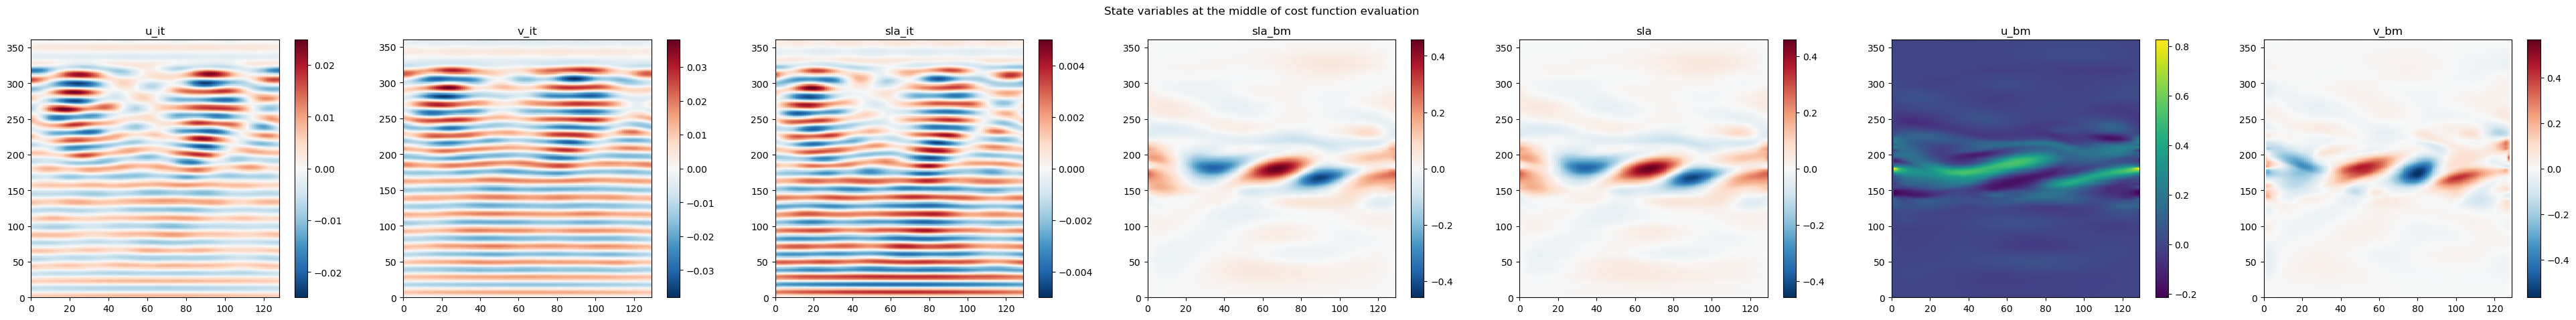

Can't plot parameters
Can't plot parameters


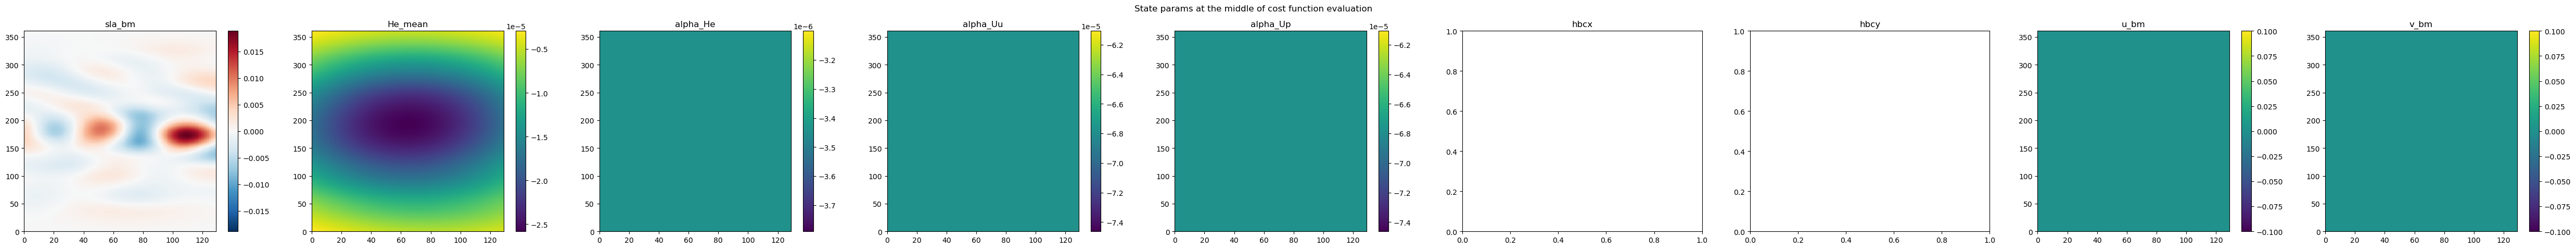

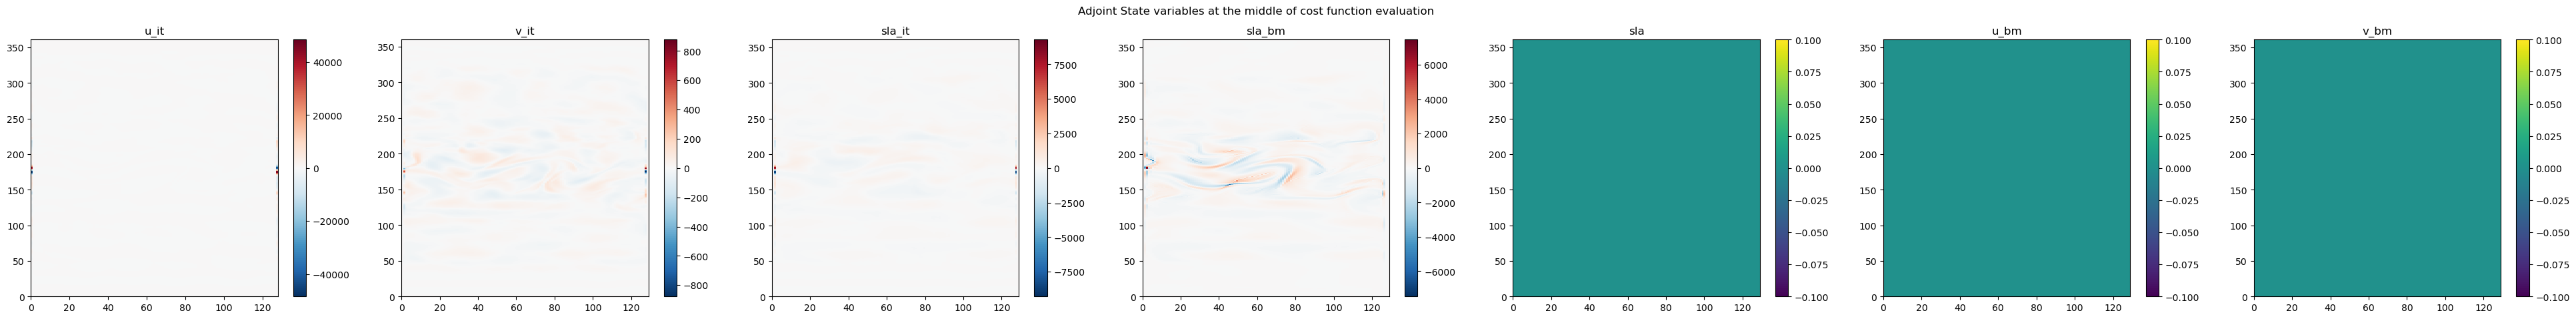

* iteration 20 computed in 2.20E+01 second:, x=-1.17E-04, J=3.09E+05, G=6.77E+02, ftol=2.09E-02, gtol=1.18E-01


* iteration 21 computed in 1.73E+01 second:, x=-3.29E-04, J=3.03E+05, G=7.98E+02, ftol=1.93E-02, gtol=1.52E-01


* iteration 22 computed in 1.73E+01 second:, x=-3.26E-04, J=3.02E+05, G=2.02E+03, ftol=3.67E-03, gtol=6.05E-01


* iteration 23 computed in 1.73E+01 second:, x=-6.14E-04, J=2.92E+05, G=7.16E+02, ftol=3.09E-02, gtol=6.45E-01


* iteration 24 computed in 1.73E+01 second:, x=-7.66E-04, J=2.89E+05, G=5.40E+02, ftol=1.12E-02, gtol=2.46E-01


* iteration 25 computed in 1.73E+01 second:, x=-1.03E-03, J=2.84E+05, G=6.96E+02, ftol=1.60E-02, gtol=2.24E-01


* iteration 26 computed in 1.72E+01 second:, x=-1.40E-03, J=2.78E+05, G=7.52E+02, ftol=2.15E-02, gtol=7.45E-02


* iteration 27 computed in 1.72E+01 second:, x=-2.34E-03, J=2.73E+05, G=1.72E+03, ftol=1.77E-02, gtol=5.64E-01


* iteration 28 computed in 1.73E+01 second:, x=-2.56E-03, J=2.65E+05, G=6.39E+02, ftol=3.00E-02, gtol=6.29E-01


* iteration 29 computed in 1.72E+01 second:, x=-2.50E-03, J=2.63E+05, G=4.31E+02, ftol=8.25E-03, gtol=3.26E-01


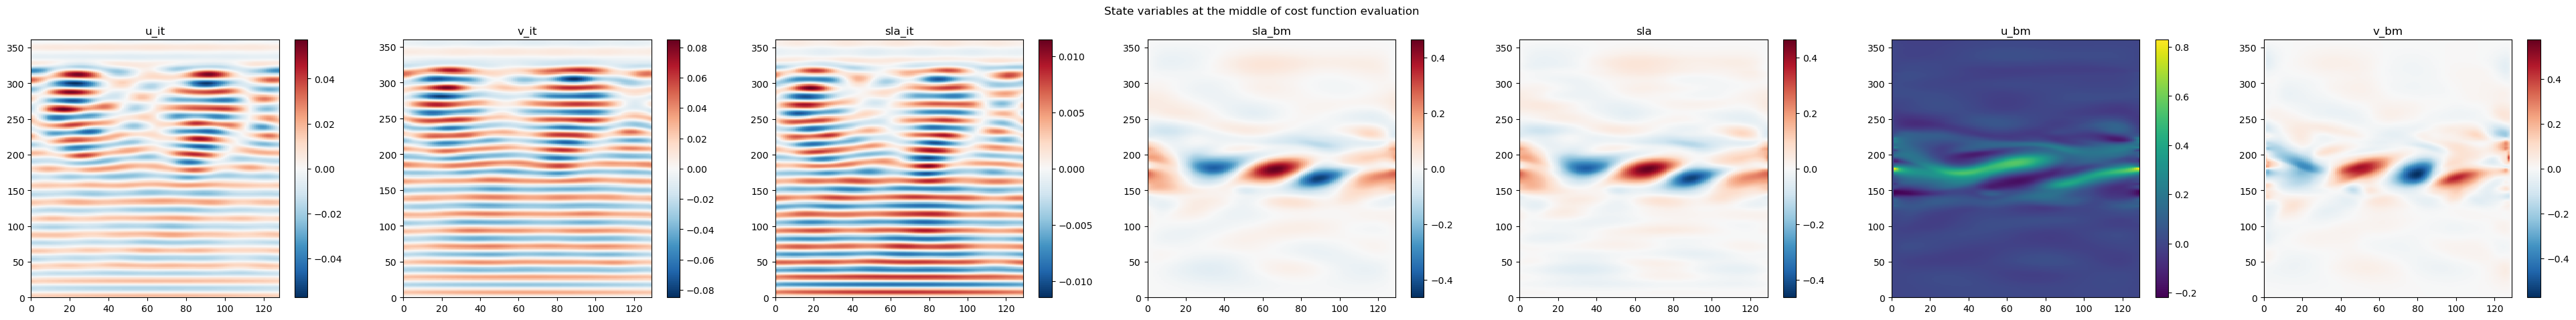

Can't plot parameters
Can't plot parameters


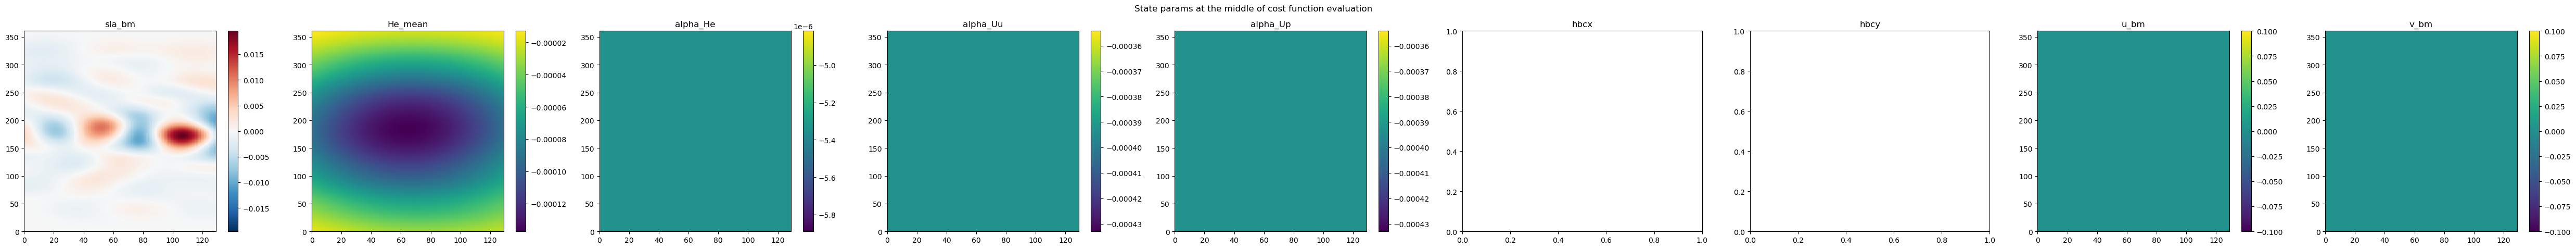

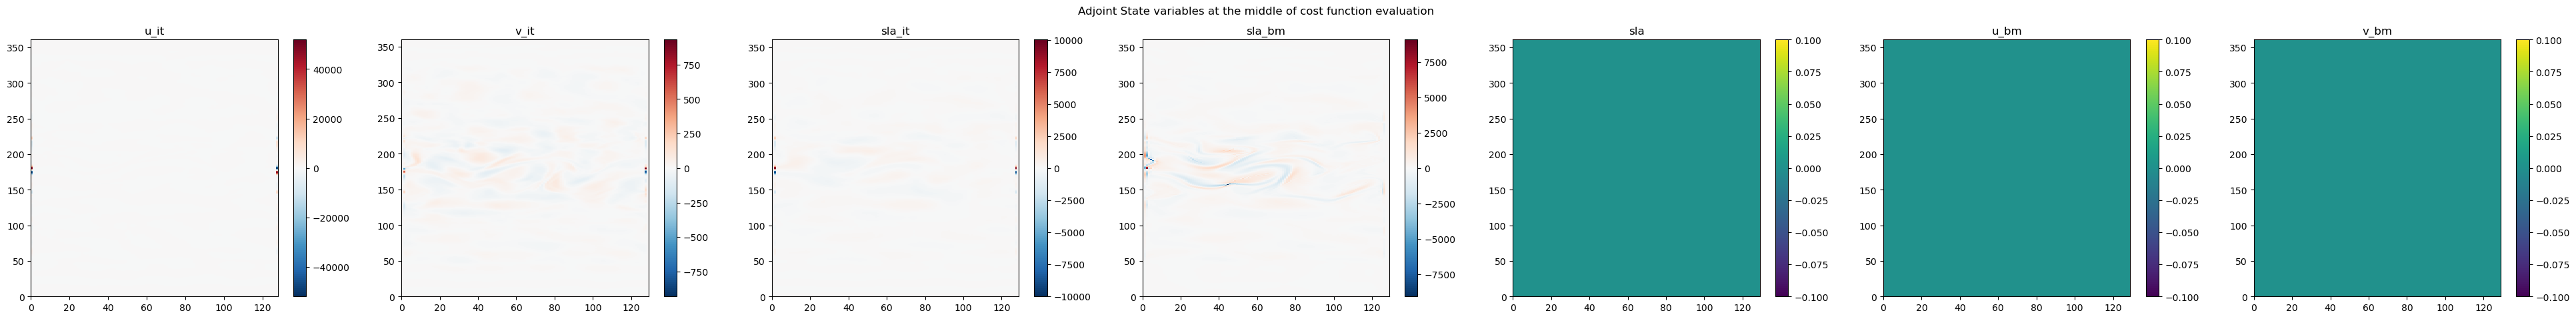

* iteration 30 computed in 2.13E+01 second:, x=-2.60E-03, J=2.60E+05, G=5.04E+02, ftol=1.22E-02, gtol=1.45E-01


* iteration 31 computed in 1.73E+01 second:, x=-2.90E-03, J=2.56E+05, G=6.60E+02, ftol=1.41E-02, gtol=2.36E-01


* iteration 32 computed in 1.73E+01 second:, x=-3.53E-03, J=2.51E+05, G=1.02E+03, ftol=1.82E-02, gtol=3.56E-01


* iteration 33 computed in 1.73E+01 second:, x=-3.95E-03, J=2.46E+05, G=6.77E+02, ftol=2.17E-02, gtol=3.39E-01


* iteration 34 computed in 1.73E+01 second:, x=-4.49E-03, J=2.40E+05, G=6.29E+02, ftol=2.26E-02, gtol=7.04E-02


* iteration 35 computed in 1.73E+01 second:, x=-4.87E-03, J=2.37E+05, G=7.24E+02, ftol=1.26E-02, gtol=1.31E-01


* iteration 36 computed in 1.73E+01 second:, x=-5.18E-03, J=2.34E+05, G=5.48E+02, ftol=1.55E-02, gtol=2.44E-01


* iteration 37 computed in 1.73E+01 second:, x=-5.67E-03, J=2.30E+05, G=6.52E+02, ftol=1.52E-02, gtol=1.60E-01


* iteration 38 computed in 1.72E+01 second:, x=-5.93E-03, J=2.28E+05, G=7.48E+02, ftol=1.09E-02, gtol=1.29E-01


* iteration 39 computed in 1.73E+01 second:, x=-6.02E-03, J=2.26E+05, G=4.89E+02, ftol=9.10E-03, gtol=3.47E-01


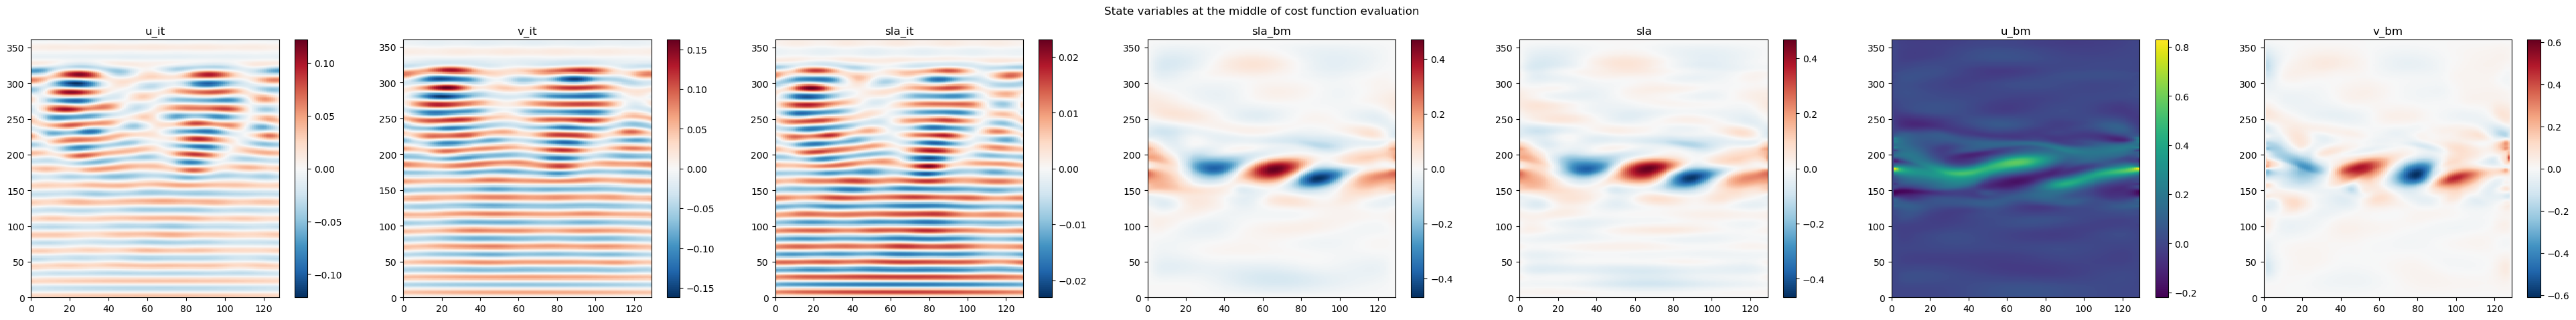

Can't plot parameters
Can't plot parameters


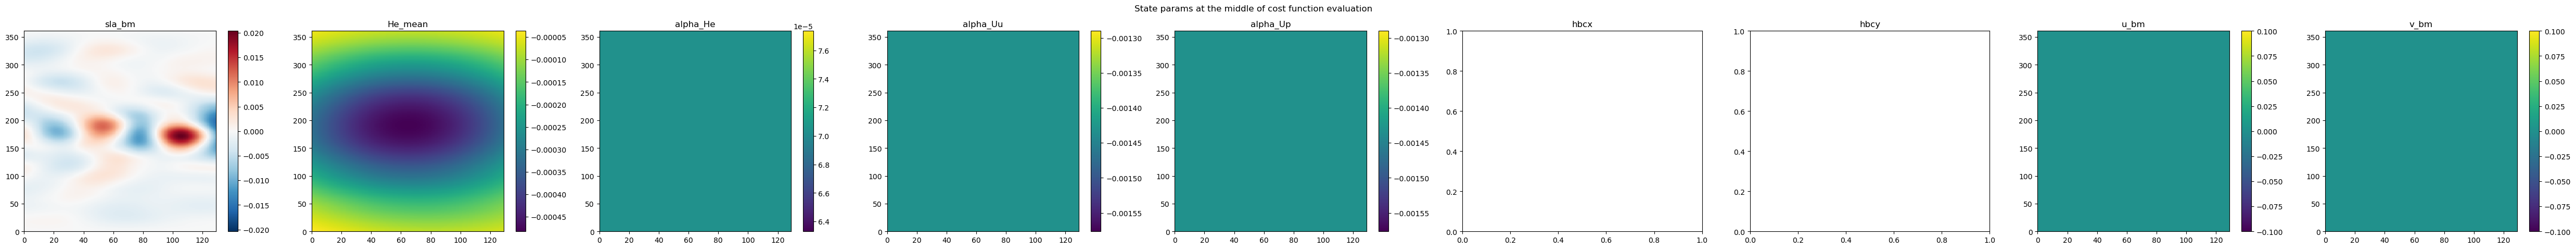

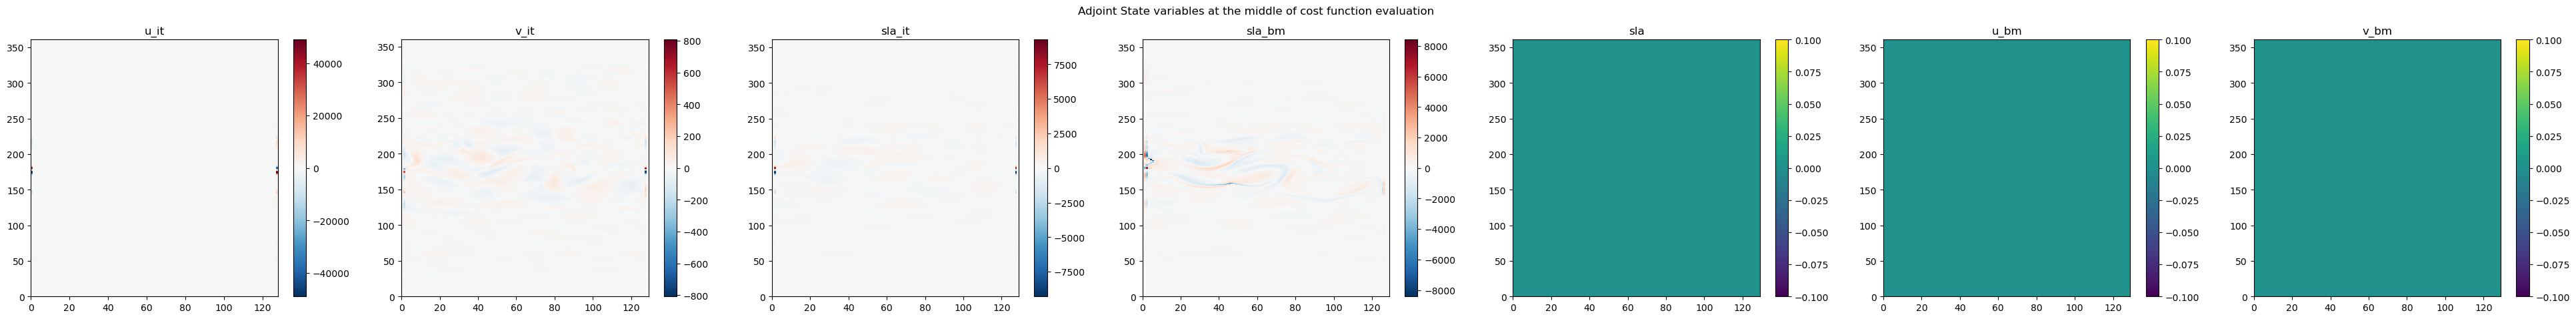

* iteration 40 computed in 2.14E+01 second:, x=-6.29E-03, J=2.23E+05, G=4.13E+02, ftol=1.28E-02, gtol=1.54E-01


* iteration 41 computed in 1.73E+01 second:, x=-6.57E-03, J=2.21E+05, G=4.81E+02, ftol=9.43E-03, gtol=1.41E-01


* iteration 42 computed in 1.74E+01 second:, x=-7.11E-03, J=2.18E+05, G=1.03E+03, ftol=1.10E-02, gtol=5.33E-01


* iteration 43 computed in 1.73E+01 second:, x=-7.41E-03, J=2.14E+05, G=4.89E+02, ftol=1.80E-02, gtol=5.25E-01


* iteration 44 computed in 1.72E+01 second:, x=-7.49E-03, J=2.12E+05, G=4.22E+02, ftol=1.12E-02, gtol=1.38E-01


* iteration 45 computed in 1.72E+01 second:, x=-7.64E-03, J=2.09E+05, G=4.46E+02, ftol=1.46E-02, gtol=5.52E-02


* iteration 46 computed in 1.72E+01 second:, x=-8.03E-03, J=2.05E+05, G=4.91E+02, ftol=1.62E-02, gtol=9.11E-02


* iteration 47 computed in 1.72E+01 second:, x=-8.48E-03, J=2.05E+05, G=1.03E+03, ftol=1.05E-03, gtol=5.24E-01


* iteration 48 computed in 1.72E+01 second:, x=-8.26E-03, J=2.03E+05, G=5.13E+02, ftol=8.41E-03, gtol=5.03E-01


* iteration 49 computed in 1.72E+01 second:, x=-8.44E-03, J=2.02E+05, G=3.29E+02, ftol=8.21E-03, gtol=3.59E-01


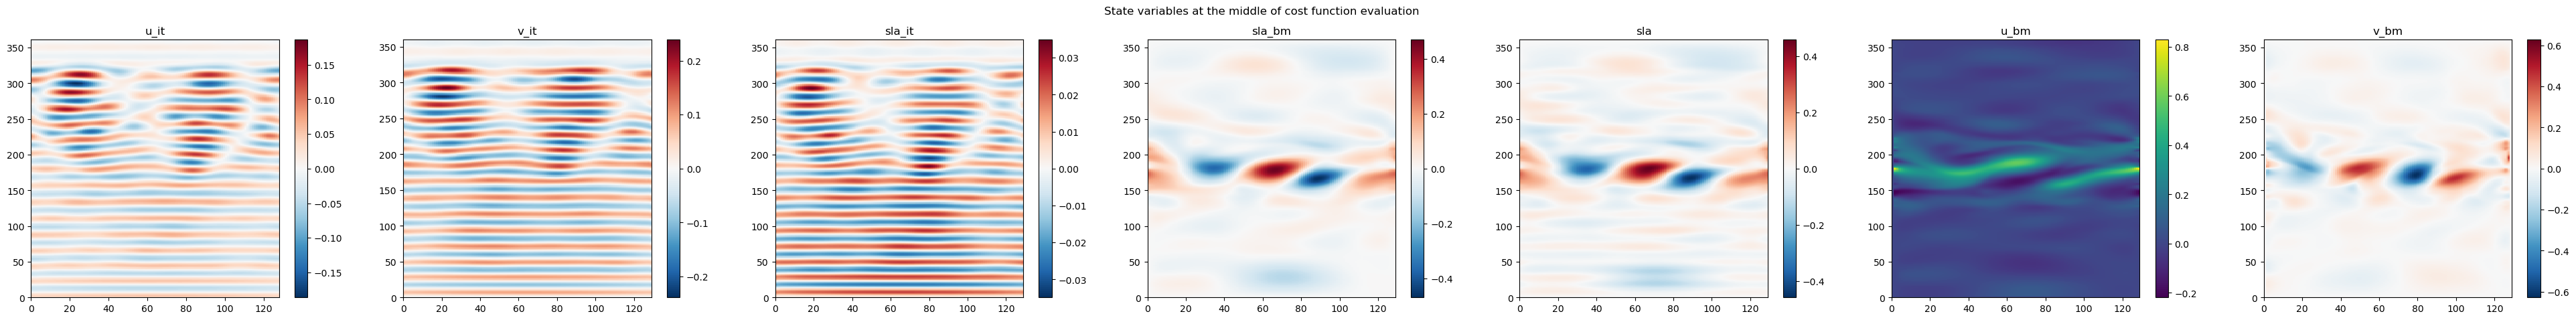

Can't plot parameters
Can't plot parameters


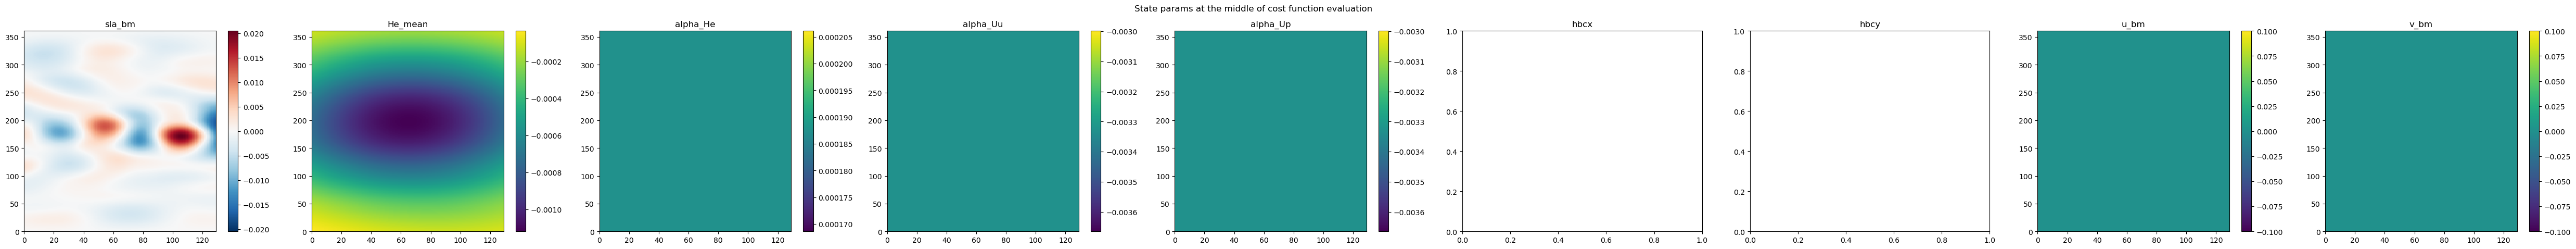

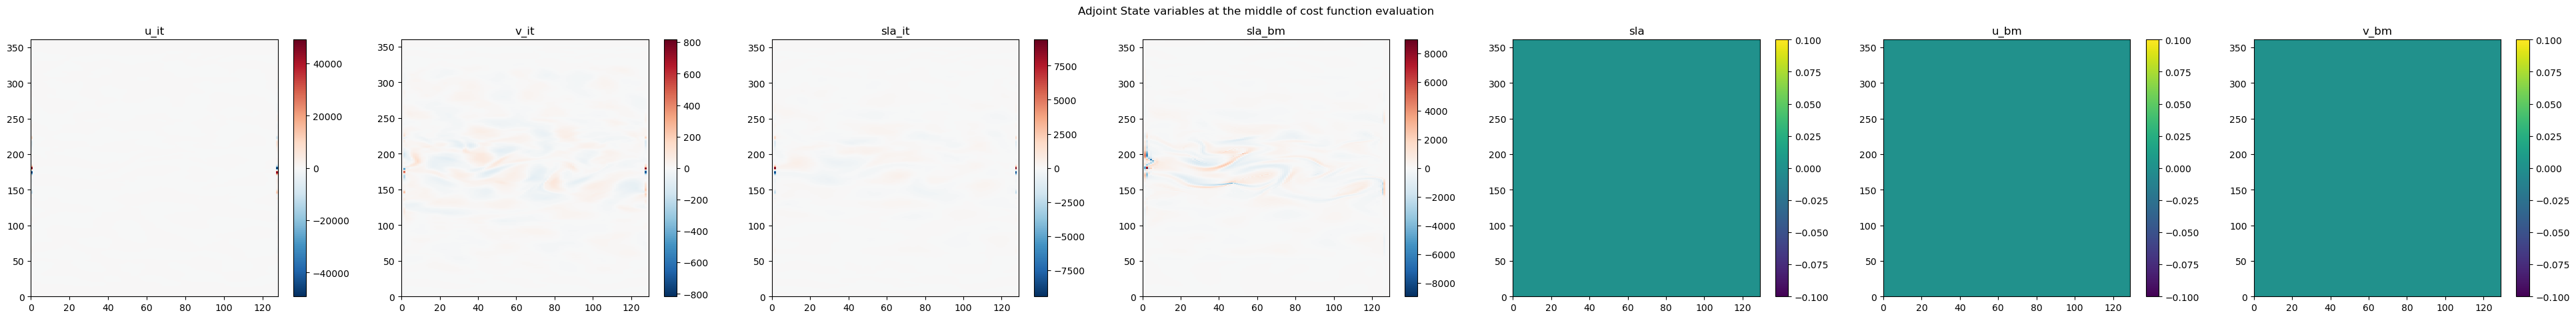

* iteration 50 computed in 2.14E+01 second:, x=-8.59E-03, J=2.00E+05, G=3.80E+02, ftol=7.24E-03, gtol=1.34E-01


* iteration 51 computed in 1.73E+01 second:, x=-8.76E-03, J=1.98E+05, G=4.59E+02, ftol=9.71E-03, gtol=1.73E-01


* iteration 52 computed in 1.73E+01 second:, x=-9.21E-03, J=1.98E+05, G=8.96E+02, ftol=2.28E-03, gtol=4.88E-01


* iteration 53 computed in 1.73E+01 second:, x=-9.06E-03, J=1.96E+05, G=3.41E+02, ftol=1.17E-02, gtol=6.20E-01

Is the minimization successful? False

Final cost function value: 195535.35863574856

Number of iterations: 50

*** Saving trajectory ***



In [4]:
from src import inv

inv.Inv(
    config, State, Model, dict_obs=dict_obs, Obsop=Obsop, Basis=Basis,
    gpu_device=NUM_GPU,
)

## Optional OSSE diagnostics
The diagnostic compares analysed total SLA (`sla`) with JET reference total SLA (`sla`).

super: DIAG_OSSE
dir_output: ./diags/VarDyn-BMIT-JET
time_min: None
time_max: None
time_step: None
lon_min: None
lon_max: None
lat_min: None
lat_max: None
path_images2mp4: /data1/packages/climporn/ffmpeg/images2mp4.sh
name_ref: /data1/data/models/JET_BM-IT/full_resolution/wp6_surf_data_ref_coarse2.nc
name_ref_time: time
name_ref_lon: lon
name_ref_lat: lat
name_ref_var: sla
options_ref: {}
name_exp_time: None
name_exp_lon: None
name_exp_lat: None
name_exp_var: sla
exp_grid_type: None
compare_to_baseline: False
name_bas: None
name_bas_time: time
name_bas_lon: lon
name_bas_lat: lat
name_bas_var: sla
name_mask: None
name_var_mask: {'lon': '', 'lat': '', 'var': ''}



/home/flo/VarDyn/mapping/src/diag.py:145: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  self.ref_dims = list(self.ref.dims.keys())


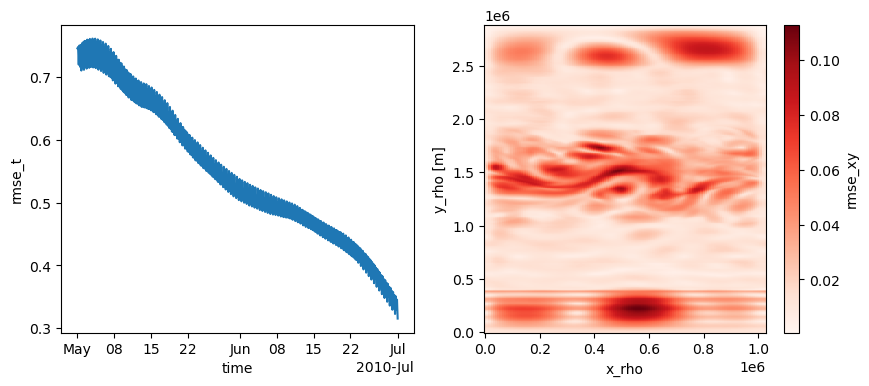

In [5]:
from src import diag

Diag = diag.Diag(config, State)
Diag.regrid_exp()
Diag.rmse_based_scores(plot=True)
# Diag.movie()  # Requires path_images2mp4 from the configuration.